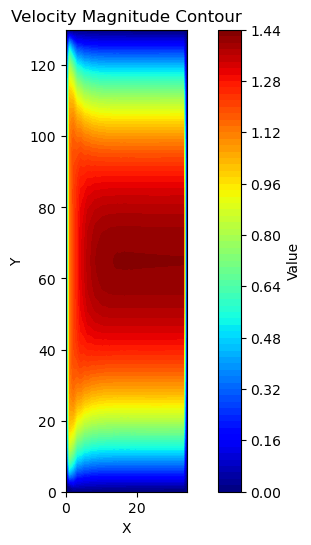

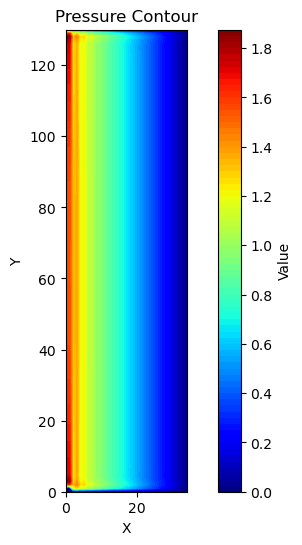

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_contour(data, x, y, title, cmap='coolwarm'):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    
   
    
    cs = ax.contourf(x, y, data, levels=80, cmap=cmap)
    fig.colorbar(cs, ax=ax, label='Value')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')  # 保持比例正确
    plt.show()
def plot_contour2(data, x, y, title, cmap='coolwarm', vmin=None, vmax=None):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    
    # 使用 vmin 和 vmax 控制颜色范围
    cs = ax.contourf(x, y, data, levels=80, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(cs, ax=ax, label='Value')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()
def load_and_combine_data(i):
    # 使用 numpy 2.x 的新 API
    u_data = []
    v_data = []
    p_data = []
    
    for idx in range(i + 1):
        # 使用 numpy.loadtxt 的新选项
        u = np.loadtxt(f'u_{idx}.dat', dtype=np.float64)
        v = np.loadtxt(f'v_{idx}.dat', dtype=np.float64)
        p = np.loadtxt(f'p_{idx}.dat', dtype=np.float64)
        
        if idx == 0:
            u_trimmed = u[:, :-2]
            v_trimmed = v[:, :-2]
            p_trimmed = p[:, :-2]
        elif idx == i:
            u_trimmed = u[:, 2:]
            v_trimmed = v[:, 2:]
            p_trimmed = p[:, 2:]
        else:
            u_trimmed = u[:, 2:-2]
            v_trimmed = v[:, 2:-2]
            p_trimmed = p[:, 2:-2]
            
        u_data.append(u_trimmed)
        v_data.append(v_trimmed)
        p_data.append(p_trimmed)
    
    # 使用新的数组连接方法
    return (np.concatenate(u_data, axis=1),
            np.concatenate(v_data, axis=1),
            np.concatenate(p_data, axis=1))

# 主程序
if __name__ == "__main__":
    i = int(input("请输入 i 的值（例如 2）: "))
    aspect_ratio = float(input("请输入 x/y 的比例（例如 5.0）: "))
    
    u_result, v_result, p_result = load_and_combine_data(i)
    
    # 保存结果
    np.savetxt('u_combined.dat', u_result)
    np.savetxt('v_combined.dat', v_result)
    np.savetxt('p_combined.dat', p_result)
    
    # 计算速度大小
    velocity_magnitude = np.sqrt(u_result**2 + v_result**2)
    
    # 网格坐标
    ny, nx = velocity_magnitude.shape
    x = np.linspace(0, nx, nx) * aspect_ratio
    y = np.linspace(0, ny, ny)
    y = y[::-1]  # 翻转 y1
    
    X, Y = np.meshgrid(x, y)
    
    # 绘图
    #plot_contour(velocity_magnitude, X, Y, 'Velocity Magnitude Contour', cmap='plasma')
    #plot_contour(p_result, X, Y, 'Pressure Contour', cmap='coolwarm')
    plot_contour(velocity_magnitude, X, Y, 'Velocity Magnitude Contour', cmap='jet')
    plot_contour(p_result, X, Y, 'Pressure Contour', cmap='jet')
